## Executive Summary

This case study analyzes PhonePe transaction and user data from 2018 to 2021 to understand trends in digital payment adoption across India. The analysis focuses on transaction growth, user engagement, demographic correlations, and regional penetration. Key insights highlight rapid adoption of digital payments, increasing transaction values, moderate influence of population density, and opportunities for expansion in underpenetrated regions.


In [82]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [232]:
file_path = r"C:\Users\choud\Downloads\phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx"
xls = pd.ExcelFile(file_path)
xls.sheet_names

['State_Txn and Users',
 'State_TxnSplit',
 'State_DeviceData',
 'District_Txn and Users',
 'District Demographics',
 'Admin']

In [84]:
state_level_data= pd.read_excel(file_path, sheet_name = 'State_Txn and Users')
Category_wise_transactions= pd.read_excel(file_path, sheet_name = 'State_TxnSplit')
Device_adoption = pd.read_excel(file_path, sheet_name = 'State_DeviceData')
district_level_data = pd.read_excel(file_path, sheet_name = 'District_Txn and Users')
District_Demographics = pd.read_excel(file_path, sheet_name = 'District Demographics')

In [5]:
print("First 5 rows of state-level data:")
print(state_level_data.head(5))

First 5 rows of state-level data:
                       State  Year  Quarter  Transactions  Amount (INR)  \
0  Andaman & Nicobar Islands  2018        1          6658  1.463176e+07   
1  Andaman & Nicobar Islands  2018        2         11340  2.833854e+07   
2  Andaman & Nicobar Islands  2018        3         16265  5.555747e+07   
3  Andaman & Nicobar Islands  2018        4         23758  9.054834e+07   
4  Andaman & Nicobar Islands  2019        1         30486  1.022997e+08   

     ATV (INR)  Registered Users  App Opens  
0  2197.621091              6740          0  
1  2498.989022              9405          0  
2  3415.768284             12149          0  
3  3811.277720             15222          0  
4  3355.630147             18596          0  


In [11]:
print("\n Bottom 10 rows of Category-wise transactions dataset:")
print(Category_wise_transactions.tail(10))


 Bottom 10 rows of Category-wise transactions dataset:
            State  Year  Quarter          Transaction Type  Transactions  \
2504  West Bengal  2021        1     Peer-to-peer payments      53869075   
2505  West Bengal  2021        1         Merchant payments      37143701   
2506  West Bengal  2021        1  Recharge & bill payments      26673733   
2507  West Bengal  2021        1        Financial Services        166727   
2508  West Bengal  2021        1                    Others        400816   
2509  West Bengal  2021        2     Peer-to-peer payments      64661051   
2510  West Bengal  2021        2         Merchant payments      41696787   
2511  West Bengal  2021        2  Recharge & bill payments      34799709   
2512  West Bengal  2021        2        Financial Services        190537   
2513  West Bengal  2021        2                    Others        549353   

      Amount (INR)    ATV (INR)  
2504  2.022402e+11  3754.292226  
2505  2.891834e+10   778.553104  
2506 

In [5]:
mid = len(Device_adoption)//2
print("\n Middle 10 rows of Device adoption dataset:")
print(Device_adoption.iloc[mid-5 : mid+5])


 Middle 10 rows of Device adoption dataset:
            State  Year  Quarter     Brand  Registered Users  Percentage
2767       Ladakh  2021        2   OnePlus              1741    0.023198
2768       Ladakh  2021        2  Motorola               922    0.012285
2769       Ladakh  2021        2    Huawei               894    0.011912
2770       Ladakh  2021        2    Lenovo               490    0.006529
2771       Ladakh  2021        2    Others              2610    0.034778
2772  Lakshadweep  2018        1   Samsung               102    0.203593
2773  Lakshadweep  2018        1    Xiaomi               100    0.199601
2774  Lakshadweep  2018        1      Vivo                67    0.133733
2775  Lakshadweep  2018        1      Oppo                56    0.111776
2776  Lakshadweep  2018        1    Huawei                25    0.049900


In [22]:
print("\n Top 10 rows of district-level data:")
print(district_level_data.head(10))

print("\n Bottom 10 rows of district-level data:")
print(district_level_data.tail(10))


 Top 10 rows of district-level data:
                       State  Year  Quarter                  District  Code  \
0  Andaman & Nicobar Islands  2018        1                  Nicobars  AN01   
1  Andaman & Nicobar Islands  2018        1  North And Middle Andaman  AN02   
2  Andaman & Nicobar Islands  2018        1             South Andaman  AN03   
3  Andaman & Nicobar Islands  2018        2                  Nicobars  AN01   
4  Andaman & Nicobar Islands  2018        2  North And Middle Andaman  AN02   
5  Andaman & Nicobar Islands  2018        2             South Andaman  AN03   
6  Andaman & Nicobar Islands  2018        3                  Nicobars  AN01   
7  Andaman & Nicobar Islands  2018        3  North And Middle Andaman  AN02   
8  Andaman & Nicobar Islands  2018        3             South Andaman  AN03   
9  Andaman & Nicobar Islands  2018        4                  Nicobars  AN01   

   Transactions  Amount (INR)    ATV (INR)  Registered Users  App Opens  
0           528  1

In [6]:
print("\n every 10th row of District Demographics:")
print(District_Demographics.iloc[9::10])


 every 10th row of District Demographics:
                         State       District     Headquarters  Population  \
9               Andhra Pradesh     Srikakulam       Srikakulam     2699471   
19           Arunachal Pradesh   Kurung Kumey        Koloriang       89717   
29           Arunachal Pradesh       Shi Yomi             Tato       13310   
39                       Assam         Bajali         Pathsala      253816   
49                       Assam      Dibrugarh        Dibrugarh     1327748   
..                         ...            ...              ...         ...   
699  Andaman & Nicobar Islands  South Andaman       Port Blair      238142   
709            Jammu & Kashmir      Ganderbal        Ganderbal      297003   
719            Jammu & Kashmir          Reasi            Reasi      314714   
729                      Delhi      New Delhi  Connaught Place      142004   
739                 Puducherry           Mahé             Mahé       41816   

     Area (sq km)  D

In [7]:
#basic statistics of each dataset
state_level_data.describe()
Category_wise_transactions.describe()
Device_adoption.describe()
district_level_data.describe()
District_Demographics.describe()

,Population,Area (sq km),Density
count,7.420000e+02,742.000000,742.000000
mean,1.668555e+06,4395.373120,838.512129
std,1.458849e+06,4254.676124,2754.406896
min,0.000000e+00,0.000000,0.000000
25%,6.530815e+05,2039.750000,198.000000
50%,1.322359e+06,3402.500000,353.000000
75%,2.297440e+06,5432.750000,686.250000
max,1.008285e+07,45652.000000,36155.000000


In [8]:
# data types
state_level_data.dtypes
Category_wise_transactions.dtypes
Device_adoption.dtypes
district_level_data.dtypes
District_Demographics.dtypes

State              object
District           object
Headquarters       object
Population          int64
Area (sq km)      float64
Density             int64
Code               object
Alternate Name     object
dtype: object

Idetifying missing values and calculating the percentage of missing values for each column and 
highlighting the highest percentage of the same.

In [147]:
missing_summery = pd.DataFrame({
    'Missing values': state_level_data.isnull().sum(),
    'Missing %': (state_level_data.isnull().mean()*100)})

missing_summery.style.highlight_max(subset=['Missing %'], color='lightcoral')

,Missing values,Missing %
State,0,0.000000
Year,0,0.000000
Quarter,0,0.000000
Transactions,0,0.000000
Amount (INR),1,0.198413
ATV (INR),0,0.000000
Registered Users,0,0.000000
App Opens,0,0.000000


In [10]:
missing_summery = pd.DataFrame({
    'Missing values': Category_wise_transactions.isnull().sum(),
    'Missing %': (Category_wise_transactions.isnull().mean()*100)})

missing_summery.style.highlight_max(subset=['Missing %'], color='lightcoral')

,Missing values,Missing %
State,0,0.000000
Year,0,0.000000
Quarter,0,0.000000
Transaction Type,0,0.000000
Transactions,0,0.000000
Amount (INR),0,0.000000
ATV (INR),0,0.000000


In [60]:
missing_summery = pd.DataFrame({
    'Missing values': Device_adoption.isnull().sum(),
    'Missing %': (Device_adoption.isnull().mean()*100)})

missing_summery.style.highlight_max(subset=['Missing %'], color='lightcoral')

,Missing values,Missing %
State,0,0.000000
Year,0,0.000000
Quarter,0,0.000000
Brand,0,0.000000
Registered Users,0,0.000000
Percentage,0,0.000000


In [9]:
missing_summery = pd.DataFrame({
    'Missing values': district_level_data.isnull().sum(),
    'Missing %': (district_level_data.isnull().mean()*100)})

missing_summery.style.highlight_max(subset=['Missing %'], color='lightcoral')

,Missing values,Missing %
State,0,0.000000
Year,0,0.000000
Quarter,0,0.000000
District,0,0.000000
Code,0,0.000000
Transactions,0,0.000000
Amount (INR),0,0.000000
ATV (INR),4,0.039032
Registered Users,0,0.000000
App Opens,0,0.000000


In [149]:
# imputing missing values

district_level_data['Code'].fillna('Unknown')
#there were 28 missing values in this dataset in column name code, so replaced them with unknown

0        AN01
1        AN02
2        AN03
3        AN01
4        AN02
         ... 
10243    WB19
10244    WB20
10245    WB21
10246    WB22
10247    WB23
Name: Code, Length: 10248, dtype: object

In [148]:
missing_summery = pd.DataFrame({
    'Missing values': District_Demographics.isnull().sum(),
    'Missing %': (District_Demographics.isnull().mean()*100)})

missing_summery.style.highlight_max(subset=['Missing %'], color='lightcoral')

,Missing values,Missing %
State,0,0.000000
District,0,0.000000
Headquarters,0,0.000000
Population,0,0.000000
Area (sq km),0,0.000000
Density,0,0.000000
Code,0,0.000000
Alternate Name,0,0.000000


In [152]:
# total number of states and districts and identifying the state with highest number of districts

print("total number of states:")
print(district_level_data['State'].nunique())

print("total number of districts:")
print(district_level_data['District'].nunique())

unique_state_district = district_level_data[['State', 'District']].drop_duplicates()
districts_per_state = unique_state_district['State'].value_counts()

print("state with highest number of districts:")
print(districts_per_state.idxmax(),districts_per_state.max())

total number of states:
36
total number of districts:
723
state with highest number of districts:
Uttar Pradesh 75


Transaction trend over the years

In [100]:
# total number of tranasactions and total transaction amount for each state over the years

state_year_trend = state_level_data.groupby(['State', 'Year']).agg(
     Total_Transactions = ('Transactions', 'sum'),
    Total_Amount = ('Amount (INR)', 'sum')).reset_index()

state_year_trend

,State,Year,Total_Transactions,Total_Amount
0,Andaman & Nicobar Islands,2018,58021,1.890761e+08
1,Andaman & Nicobar Islands,2019,133104,4.734648e+08
2,Andaman & Nicobar Islands,2020,446274,1.296423e+09
3,Andaman & Nicobar Islands,2021,586166,1.682854e+09
4,Andhra Pradesh,2018,77779112,1.220720e+11
...,...,...,...,...
139,Uttarakhand,2021,44608834,7.727901e+10
140,West Bengal,2018,120011635,1.115887e+11
141,West Bengal,2019,257900590,2.660145e+11
142,West Bengal,2020,304222327,5.527316e+11


In [108]:
state_year_trend_sorted = state_year_trend.sort_values('Total_Transactions', ascending = False)

print("top 5 states with highest transaction volume:")
print(state_year_trend_sorted.head(5))

print("\nbottom 5 states with highest transaction volume:")
print(state_year_trend_sorted.tail(5))

top 5 states with highest transaction volume:
           State  Year  Total_Transactions  Total_Amount
62     Karnataka  2020          1216153117  1.803284e+12
82   Maharashtra  2020          1099666770  1.678817e+12
83   Maharashtra  2021          1091476726  1.685002e+12
63     Karnataka  2021          1054446538  1.592883e+12
126    Telangana  2020           931480581  1.895187e+12

bottom 5 states with highest transaction volume:
                        State  Year  Total_Transactions  Total_Amount
0   Andaman & Nicobar Islands  2018               58021  1.890761e+08
74                Lakshadweep  2020               32610  8.186344e+07
75                Lakshadweep  2021               20469  5.442625e+07
73                Lakshadweep  2019               12276  3.895033e+07
72                Lakshadweep  2018                6255  1.691867e+07


In [153]:
# checking duplicates
state_level_data.duplicated().any()
state_level_data.duplicated().sum()
Category_wise_transactions.duplicated().any()
Device_adoption.duplicated().any()
district_level_data.duplicated().any()
District_Demographics.duplicated().any()

np.False_

In [48]:
# for each state and quarter, determine most frequent transaction type 

most_frequent_txn = (Category_wise_transactions
    .groupby(['State', 'Quarter'])['Transaction Type']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index(name='Most_Frequent_Transaction_Type'))

most_frequent_txn

,State,Quarter,Most_Frequent_Transaction_Type
0,Andaman & Nicobar Islands,1,Recharge & bill payments
1,Andaman & Nicobar Islands,2,Recharge & bill payments
2,Andaman & Nicobar Islands,3,Recharge & bill payments
3,Andaman & Nicobar Islands,4,Recharge & bill payments
4,Andhra Pradesh,1,Recharge & bill payments
...,...,...,...
139,Uttarakhand,4,Peer-to-peer payments
140,West Bengal,1,Recharge & bill payments
141,West Bengal,2,Peer-to-peer payments
142,West Bengal,3,Peer-to-peer payments


In [63]:
#For each state, which device brand has the highest number of registered users?

brand_users = (Device_adoption.groupby(['State', 'Brand'])['Registered Users'].sum().reset_index())

top_brand_per_state = (brand_users.sort_values('Registered Users', ascending = False).drop_duplicates(subset = 'State').reset_index(drop = True))

top_brand_per_state    

,State,Brand,Registered Users
0,Maharashtra,Xiaomi,80281858
1,Uttar Pradesh,Xiaomi,64303360
2,Karnataka,Xiaomi,52595345
3,Andhra Pradesh,Xiaomi,40061549
4,Telangana,Xiaomi,38954882
5,West Bengal,Xiaomi,38265764
6,Rajasthan,Xiaomi,33767499
7,Bihar,Xiaomi,33721314
8,Madhya Pradesh,Xiaomi,32789227
9,Tamil Nadu,Xiaomi,31519236


In [159]:
# for each state, identifying district with highest population

highest_population = (District_Demographics.sort_values('Population', ascending = False).drop_duplicates('State').reset_index(drop = True))

highest_population

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,West Bengal,North 24 Parganas,Barasat,10082852,4094.00,2463,WB16,North Twenty Four Parganas
1,Karnataka,Bangalore Urban,Bangalore,9588910,2190.00,4378,KA04,Bengaluru Urban
2,Maharashtra,Pune,Pune,9426959,15643.00,603,MH26,Pune
3,Gujarat,Ahmedabad,Ahmedabad,7208200,8707.00,890,GJ01,Ahmadabad
4,Tamil Nadu,Chennai,Chennai,7139882,426.00,17000,TN03,Chennai
5,Rajasthan,Jaipur,Jaipur,6663971,11152.00,598,RJ16,Jaipur
6,Uttar Pradesh,Allahabad,Allahabad,5959798,5481.00,1087,UP03,Prayagraj
7,Bihar,Patna,Patna,5772804,3202.00,1803,BR26,Patna
8,Andhra Pradesh,East Godavari,Kakinada,5151549,10807.00,477,AP03,East Godavari
9,Kerala,Malappuram,Malappuram,4110956,3554.00,1058,KL09,Malappuram


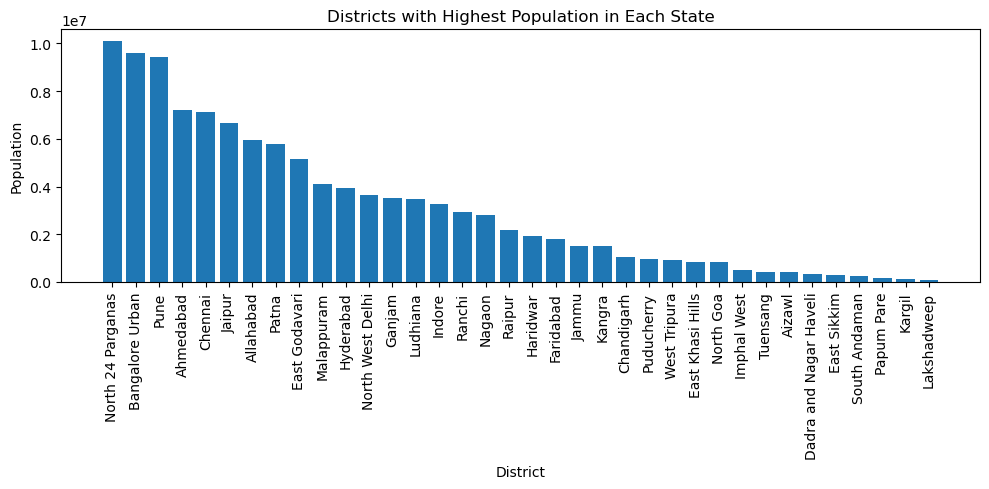

In [160]:
#column chart depicting the districts with highest population

import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))
plt.bar(highest_population['District'], highest_population['Population'])
plt.title('Districts with Highest Population in Each State')
plt.xticks(rotation = 90)
plt.xlabel('District')
plt.ylabel('Population')
plt.tight_layout()
plt.show()

In [161]:
# average transaction value(ATV) for each state

atv_per_state = state_level_data.groupby('State')['ATV (INR)'].mean().reset_index()

atv_per_state 

,State,ATV (INR)
0,Andaman & Nicobar Islands,3159.266422
1,Andhra Pradesh,1748.091476
2,Arunachal Pradesh,2638.323985
3,Assam,2008.495656
4,Bihar,2023.316978
5,Chandigarh,2113.797075
6,Chhattisgarh,1650.818617
7,Dadra & Nagar Haveli and Daman & Diu,1487.395599
8,Delhi,1589.839307
9,Goa,1895.258549


In [61]:
atv_per_state_sorted = atv_per_state.sort_values('ATV (INR)', ascending = False)

print("top 5 states with highest (ATV):")
print(atv_per_state_sorted.head(5))

print("\ntop 5 states with lowest (ATV):")
print(atv_per_state_sorted.tail(5))

top 5 states with highest (ATV):
                        State    ATV (INR)
17                     Ladakh  3408.222984
0   Andaman & Nicobar Islands  3159.266422
23                    Mizoram  2927.517802
18                Lakshadweep  2776.118701
2           Arunachal Pradesh  2638.323985

top 5 states with lowest (ATV):
                                   State    ATV (INR)
15                             Karnataka  1517.392249
20                           Maharashtra  1516.361820
7   Dadra & Nagar Haveli and Daman & Diu  1487.395599
25                                Odisha  1428.137367
35                           West Bengal  1373.600590


In [223]:
# total number of apps open over the years and quarter for each state

total_App_Opens = state_level_data.groupby(['State', 'Year','Quarter'])['App Opens'].sum().reset_index()
total_App_Opens

,State,Year,Quarter,App Opens
0,Andaman & Nicobar Islands,2018,1,0
1,Andaman & Nicobar Islands,2018,2,0
2,Andaman & Nicobar Islands,2018,3,0
3,Andaman & Nicobar Islands,2018,4,0
4,Andaman & Nicobar Islands,2019,1,0
...,...,...,...,...
499,West Bengal,2020,2,198589332
500,West Bengal,2020,3,246554831
501,West Bengal,2020,4,291721919
502,West Bengal,2021,1,316832674


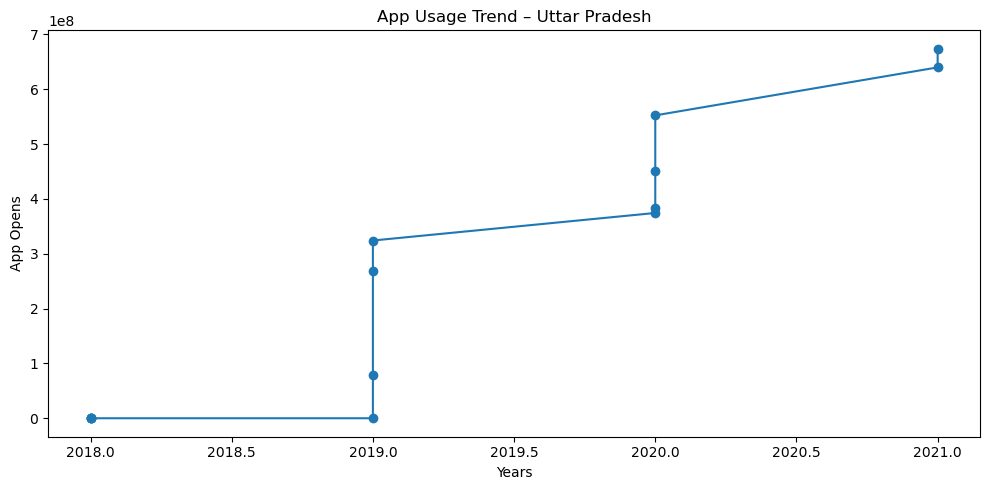

In [229]:
# trend in app usage by creating line plot showing the number of apps open over time for a selected state

selected_state = 'Uttar Pradesh'

state_trend = (total_App_Opens[total_App_Opens['State'] == selected_state].sort_values(['Year', 'Quarter']))

plt.figure(figsize = (10,5))
plt.plot(state_trend['Year'], state_trend['App Opens'],marker='o')
plt.xlabel('Years')
plt.ylabel('App Opens')
plt.title(f'App Usage Trend – {selected_state}')
plt.tight_layout()
plt.show()

### Insight:
App usage trends reflect user engagement and retention, not just adoption.This line plot shows a consistent upward trend since 2019 in app usage over time for the selected state, indicating increasing user engagement with the PhonePe application. This suggests that users are not only adopting the platform but are also interacting with it more frequently. The sustained growth in app opens reflects improved user retention, growing trust in digital payments, and an expanding range of use cases within the app.


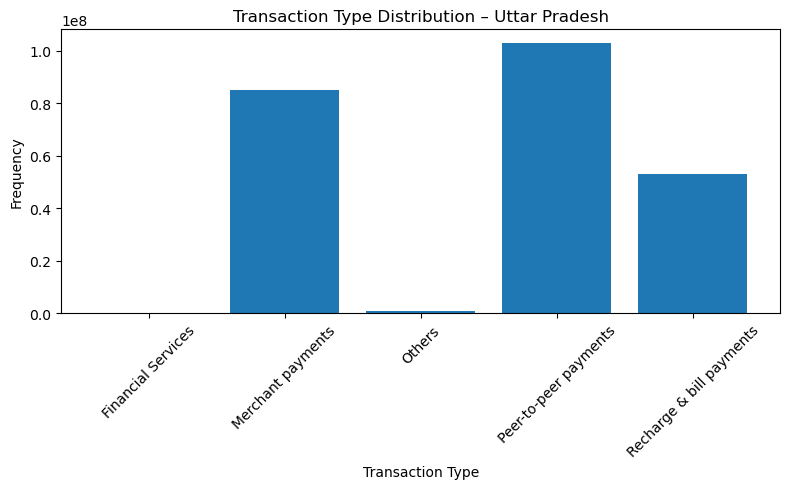

In [220]:
# bar chart showing the distribution of different transaction types for each state for most recent quarter

latest_year = Category_wise_transactions['Year'].max()

latest_quarter = (Category_wise_transactions[Category_wise_transactions['Year'] == latest_year]['Quarter'].max())

recent_data = Category_wise_transactions[(Category_wise_transactions['Year']==latest_year)&(Category_wise_transactions['Quarter']==latest_quarter)]

txn_dist = (recent_data.groupby(['State', 'Transaction Type'])['Transactions'].sum().reset_index())

selected_state = 'Uttar Pradesh'

state_txn = txn_dist[txn_dist['State'] == selected_state]

plt.figure(figsize=(8, 5))
plt.bar(state_txn['Transaction Type'], state_txn['Transactions'])
plt.xlabel('Transaction Type')
plt.ylabel('Frequency')
plt.title(f'Transaction Type Distribution – {selected_state}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight:
The bar chart reveals the user behavior that a few transaction categories contribute disproportionately to total transaction volume. This indicates that users rely heavily on PhonePe for essential and recurring payment needs rather than occasional use, highlighting strong platform stickiness.


In [113]:
# one-to-one mapping between district codes and district names using nunique() and extracting unique mappings after confirming consistency

District_Demographics.groupby('Code')['District'].nunique()

district_code_mapping = (District_Demographics[['Code', 'District']].drop_duplicates().reset_index(drop=True))

District_Demographics.groupby(['Code', 'District']).size()

#Saving it as a CSV file
district_code_mapping.to_csv('district_code_name_mapping.csv',index=False)

# reading the file
df = pd.read_csv('district_code_name_mapping.csv')

df.head()

,Code,District
0,AP01,Anantapur
1,AP02,Chittoor
2,AP03,East Godavari
3,AP04,Guntur
4,AP13,YSR


In [120]:
# for each state calculating the total transaction amount, 
#total number of transactions and total registered users 
#by summing up the values from district level data

state_aggregates = (district_level_data.groupby('State').agg({'Transactions':'sum','Amount (INR)': 'sum','Registered Users':'sum'}).reset_index())
state_aggregates.head()

# comparing the aggregated district-level totals with the existing state-level data to ensure consistency.

state_level_subset = state_level_data[['State', 'Transactions', 'Amount (INR)', 'Registered Users']]

comparison = state_aggregates.merge(state_level_subset,on='State',suffixes=('_district', '_state'))

comparison['Transactions_match'] = comparison['Transactions_district'] == comparison['Transactions_state']
comparison['Amount_match'] = comparison['Amount (INR)_district'] == comparison['Amount (INR)_state']
comparison['Users_match'] = comparison['Registered Users_district'] == comparison['Registered Users_state']

comparison


,State,Transactions_district,Amount (INR)_district,Registered Users_district,Transactions_state,Amount (INR)_state,Registered Users_state,Transactions_match,Amount_match,Users_match
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,6658,1.463176e+07,6740,False,False,False
1,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,11340,2.833854e+07,9405,False,False,False
2,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,16265,5.555747e+07,12149,False,False,False
3,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,23758,9.054834e+07,15222,False,False,False
4,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,30486,1.022997e+08,18596,False,False,False
...,...,...,...,...,...,...,...,...,...,...
499,West Bengal,942286041,1.452707e+12,144242183,57676797,1.000994e+11,13222022,False,False,False
500,West Bengal,942286041,1.452707e+12,144242183,79954504,1.568134e+11,14448366,False,False,False
501,West Bengal,942286041,1.452707e+12,144242183,100340645,1.991655e+11,15662093,False,False,False
502,West Bengal,942286041,1.452707e+12,144242183,118254052,2.429372e+11,16808799,False,False,False


DATA MERGING & ADVANCED ANALYSIS


1. Ratio of users to population by state

In [31]:
# Aggregating population at state level
state_population = (District_Demographics.groupby('State')['Population'].sum().reset_index())

# Aggregating Registered Users at state level

#Registered Users is a cumulative metric representing total account registrations over time.

users_state_level = (state_level_data.sort_values(['Year', 'Quarter']).groupby('State').tail(1).reset_index(drop=True))


# merging datasets
merged_data = state_population.merge(users_state_level, on = 'State', how = 'inner')

merged_data['User_to_Population_%'] = (merged_data['Registered Users'] / merged_data['Population'] *100).round(2)
final_table = merged_data[['State', 'Population', 'Registered Users','User_to_Population_%']].sort_values('User_to_Population_%', ascending = False)
final_table.reset_index(drop=True)

,State,Population,Registered Users,User_to_Population_%
0,Delhi,16787941,11182699,66.61
1,Dadra & Nagar Haveli and Daman & Diu,586956,344994,58.78
2,Telangana,36366570,18306880,50.34
3,Chandigarh,1055450,448572,42.50
4,Karnataka,60965960,25751023,42.24
5,Goa,1457723,609106,41.78
6,Haryana,25855357,10530594,40.73
7,Andhra Pradesh,49378776,19620905,39.74
8,Maharashtra,112378989,39664697,35.30
9,Uttarakhand,10116752,3004040,29.69


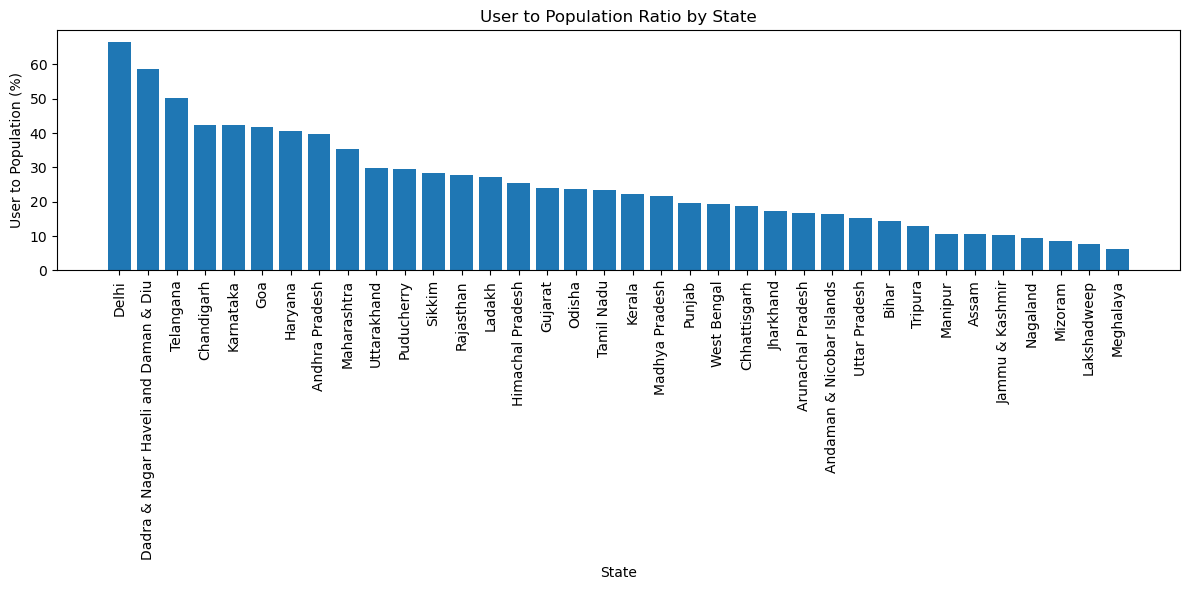

In [163]:
# column chart for User to Population Ratio by State
import matplotlib.pyplot as plt
plt.figure(figsize = (12,6))
plt.bar(final_table['State'],final_table['User_to_Population_%'])
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('User to Population (%)')
plt.title('User to Population Ratio by State')
plt.tight_layout()
plt.show()

### Insight:
User-to-population ratio helps identify true adoption levels, high population doesn’t always mean high penetration.This graph varies significantly across states, indicating uneven penetration of digital payments in India. States with higher ratios demonstrate deeper adoption of PhonePe relative to their population size, suggesting stronger digital awareness, better smartphone penetration, and higher trust in digital payment systems. Conversely, states with lower ratios represent underpenetrated markets, highlighting opportunities for targeted user acquisition, digital literacy initiatives, and localized onboarding strategies.


2. correlate population density with transaction volume
   

In [217]:
#calculating the correlation between population density and transaction volume

# Aggregating transation volume at district level 
total_transaction = (district_level_data.groupby('District')['Transactions'].sum().reset_index())

#merging datasets
merged_district = District_Demographics.merge(total_transaction, on = 'District', how = 'inner')

#correlation
correlation =  merged_district['Density'].corr(merged_district['Transactions'])
correlation

np.float64(0.4181378237782268)

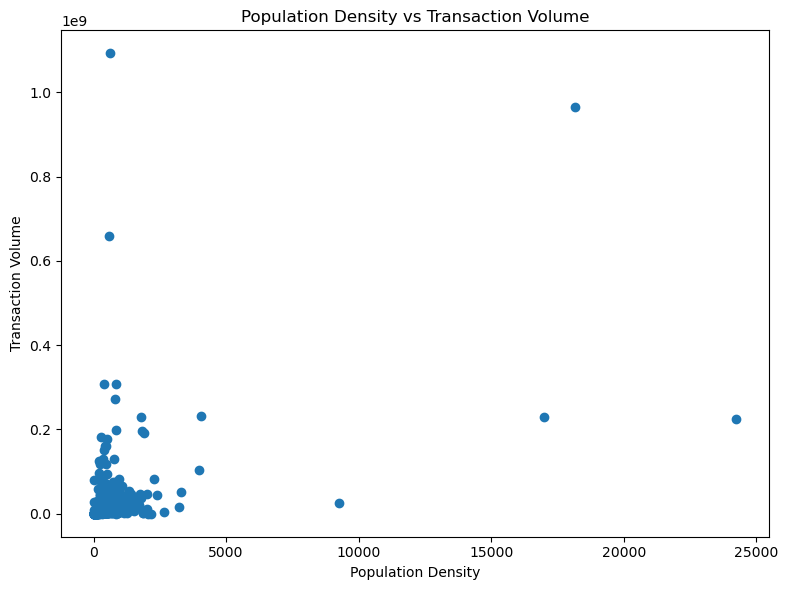

In [218]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(merged_district['Density'],merged_district['Transactions'])
plt.xlabel('Population Density')
plt.ylabel('Transaction Volume')
plt.title('Population Density vs Transaction Volume')
plt.tight_layout()
plt.show()


### Insight:
The correlation coefficient between population density and transaction volume is approximately 0.42, indicating a moderate positive relationship. This suggests that while denser regions generally show higher transaction volumes, population density alone does not determine digital payment adoption. Other factors such as internet access, smartphone penetration, and financial awareness play a critical role.


In [164]:
# average transaction amount per user for each state state 

state_aggregation = state_level_data.groupby('State').agg({'Amount (INR)': 'sum','Registered Users': 'max'}).reset_index()      
# max for cumulative users → take latest

state_aggregation['Avg_Transaction_Amount_per_User'] = (state_aggregation['Amount (INR)'] / state_aggregation['Registered Users']).round(2)
final_result = state_aggregation[['State', 'Avg_Transaction_Amount_per_User']]
final_result

,State,Avg_Transaction_Amount_per_User
0,Andaman & Nicobar Islands,58649.13
1,Andhra Pradesh,162471.99
2,Arunachal Pradesh,82239.96
3,Assam,77800.49
4,Bihar,109508.70
5,Chandigarh,119740.16
6,Chhattisgarh,85927.35
7,Dadra & Nagar Haveli and Daman & Diu,54084.37
8,Delhi,147544.19
9,Goa,72683.36


In [165]:
sorted_agg = final_result.sort_values('Avg_Transaction_Amount_per_User', ascending = False)

print("top 5 states with highest Avg Transaction Amount per User:")
print(sorted_agg.head())

print("\ntop 5 states with lowest Avg Transaction Amount per User:")
print(sorted_agg.tail())

top 5 states with highest Avg Transaction Amount per User:
             State  Avg_Transaction_Amount_per_User
31       Telangana                        249864.85
15       Karnataka                        169367.87
1   Andhra Pradesh                        162471.99
8            Delhi                        147544.19
28       Rajasthan                        138327.09

top 5 states with lowest Avg Transaction Amount per User:
                                   State  Avg_Transaction_Amount_per_User
12                      Himachal Pradesh                         56142.84
7   Dadra & Nagar Haveli and Daman & Diu                         54084.37
16                                Kerala                         50290.68
32                               Tripura                         44414.66
18                           Lakshadweep                         39248.10


In [71]:
# calculating the ratio of users using each device brand to the total number of registered users in each state

brand_users = Device_adoption.groupby(['State', 'Brand'])['Registered Users'].sum().reset_index()
total_users_state = (brand_users.groupby('State')['Registered Users'].sum().reset_index(name='Total_Registered_Users'))
merged_brand = brand_users.merge(total_users_state, on = 'State', how = 'inner')
merged_brand['Brand_User_Ratio'] = (merged_brand['Registered Users'] / merged_brand['Total_Registered_Users'] * 100).round(2)
merged_brand

,State,Brand,Registered Users,Total_Registered_Users,Brand_User_Ratio
0,Andaman & Nicobar Islands,Apple,9334,408396,2.29
1,Andaman & Nicobar Islands,Huawei,11497,408396,2.82
2,Andaman & Nicobar Islands,Lenovo,5362,408396,1.31
3,Andaman & Nicobar Islands,Motorola,9491,408396,2.32
4,Andaman & Nicobar Islands,OnePlus,15397,408396,3.77
...,...,...,...,...,...
443,West Bengal,Others,17526532,144242183,12.15
444,West Bengal,Realme,9322038,144242183,6.46
445,West Bengal,Samsung,30516315,144242183,21.16
446,West Bengal,Vivo,18755122,144242183,13.00


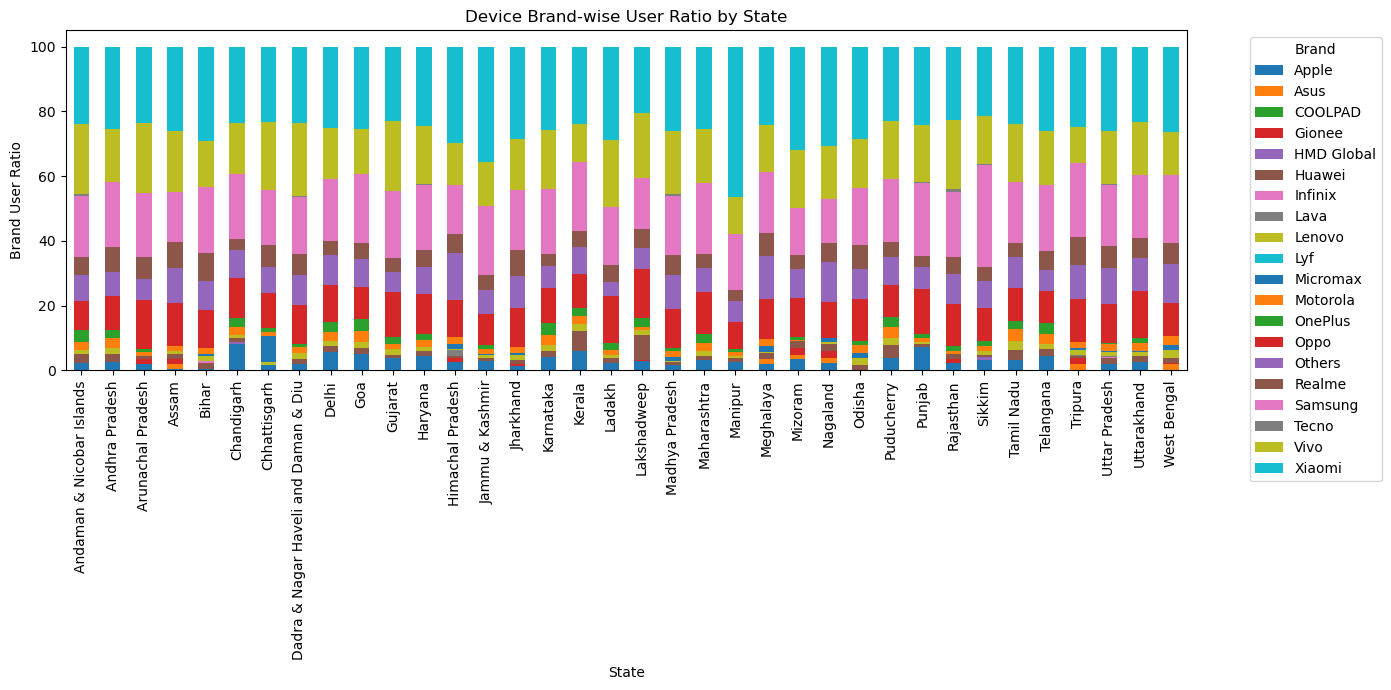

In [215]:
# Bar chart for ONE brand across states

plot_data = merged_brand.pivot(index='State',columns='Brand',values='Brand_User_Ratio')

plot_data.plot(kind='bar',stacked=True,figsize=(14,7))

plt.xlabel('State')
plt.ylabel('Brand User Ratio')
plt.title('Device Brand-wise User Ratio by State')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Insight:
The device usage distribution shows that a limited number of smartphone brands dominate user participation across states. This suggests that PhonePe’s user base is concentrated on affordable and widely available devices, highlighting the importance of optimizing the app for these platforms.


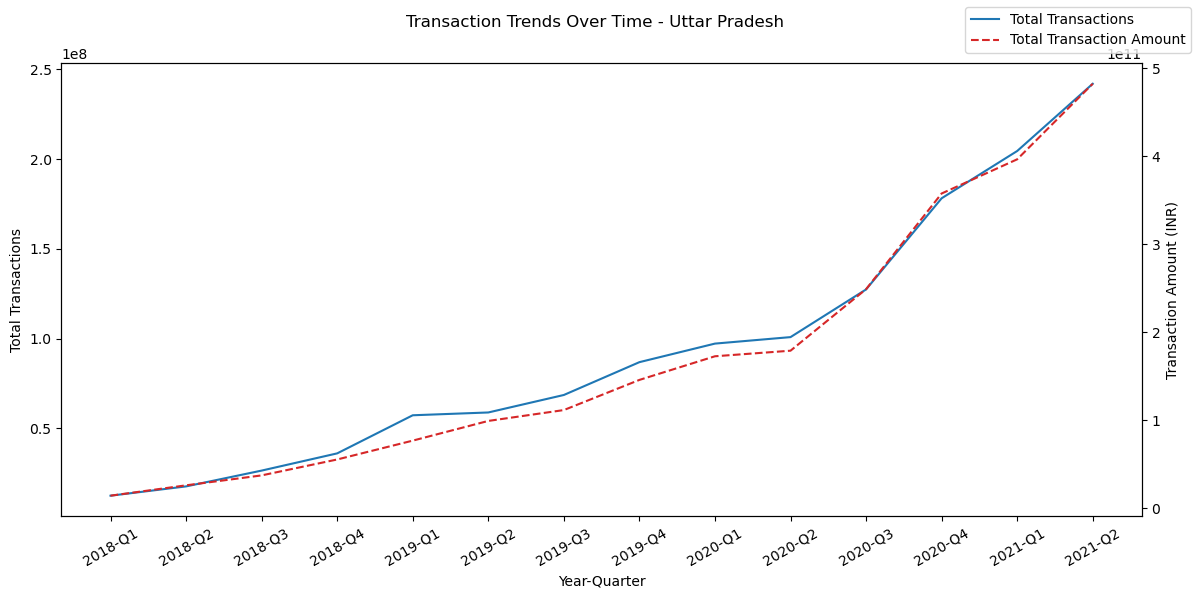

In [108]:
# Creating a line plot showing the total number of transactions and total transaction amount over time(years and quarters) for a selected state.
state_name = 'Uttar Pradesh'

df = state_level_data[state_level_data['State'] == state_name]
df = df.sort_values(['Year', 'Quarter'])
df['Time'] = df['Year'].astype(str) + '-Q' + df['Quarter'].astype(str)

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df['Time'], df['Transactions'], label='Total Transactions', color='tab:blue')
ax1.set_xlabel('Year-Quarter')
ax1.set_ylabel('Total Transactions')

ax2 = ax1.twinx()
ax2.plot(df['Time'],df['Amount (INR)'],linestyle='--',label='Total Transaction Amount',color='tab:red')
ax2.set_ylabel('Transaction Amount (INR)')

fig.suptitle(f'Transaction Trends Over Time - {state_name}')
ax1.tick_params(axis='x', rotation=30)
fig.legend()
fig.tight_layout()
plt.show()

### Insight:
The line graph shows a strong upward trend in transaction volume over time, indicating rapid adoption of digital payments across State. The growth accelerates after 2019, reflecting increased UPI awareness and pandamic lockdown. Quarterly fluctuations suggest seasonal spending patterns influenced by festivals, salary cycles, and year-end transactions.


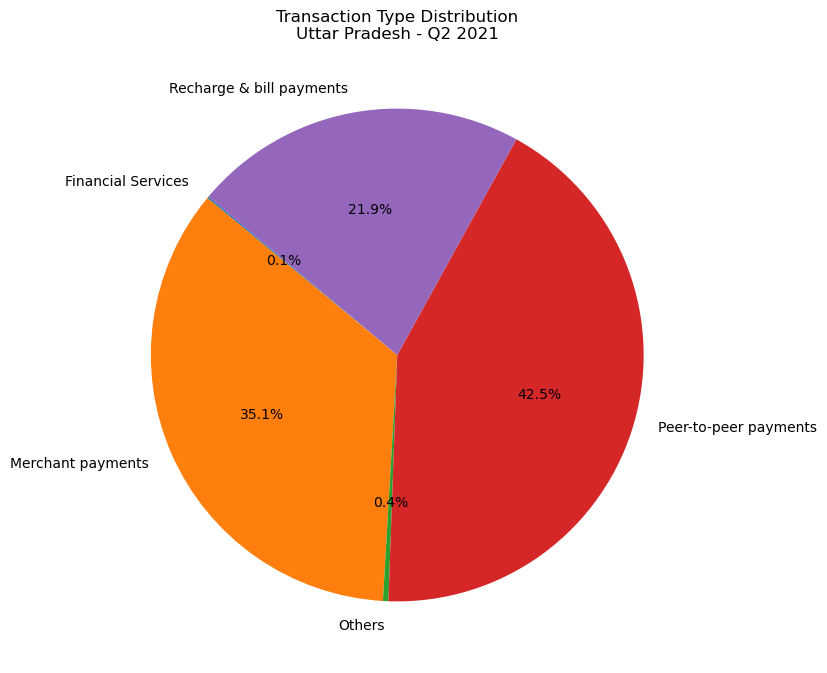

In [213]:
# Creating a pie chart showing the distribution of different transaction types for a selected state and quarter.
state_name = "Uttar Pradesh"
year = 2021
quarter = 2

filtered_df = Category_wise_transactions[(Category_wise_transactions['State'] == state_name) &(Category_wise_transactions['Year'] == year) &
    (Category_wise_transactions['Quarter'] == quarter)]

grouped = filtered_df.groupby('Transaction Type')['Transactions'].sum()

plt.figure(figsize=(8,8))
plt.pie(grouped, labels=grouped.index, autopct='%1.1f%%',startangle=140)
plt.title(f'Transaction Type Distribution\n{state_name} - Q{quarter} {year}')
plt.show()

### Insight:
The pie chart reveals the user behavior that a few transaction categories contribute disproportionately to total transaction volume. This indicates that users rely heavily on PhonePe for essential and recurring payment needs rather than occasional use, highlighting strong platform stickiness.


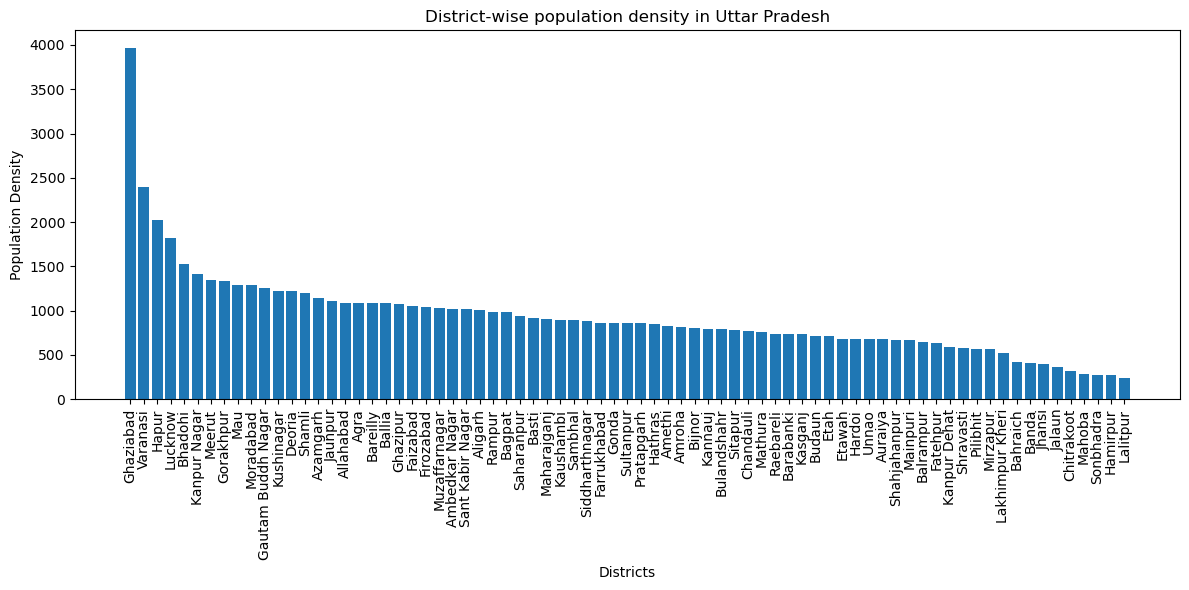

In [146]:
# creating a bar plot showing the population density of districts in a selected state.

state_name = "Uttar Pradesh"
df = District_Demographics[District_Demographics['State'] == state_name]
df = df.sort_values('Density', ascending = False)

plt.figure(figsize = (12,6))

plt.bar(df['District'], df['Density'])
plt.title(f"District-wise population density in {state_name}")
plt.xlabel('Districts')
plt.ylabel('Population Density')
plt.xticks(rotation=90,fontsize=10)
plt.tight_layout()
plt.show()

### Insight:
The bar chart highlights significant variation in population density across districts. High-density districts are potential hubs for digital transactions; however, density alone does not guarantee higher adoption, emphasizing the need to consider infrastructure and digital literacy.


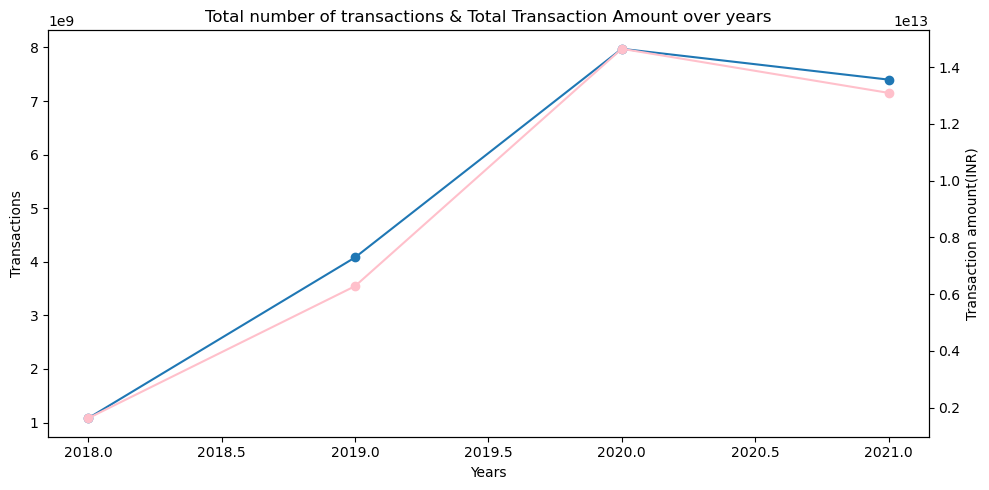

In [197]:
state_year = (state_level_data.groupby("Year")[["Transactions", "Amount (INR)"]].sum().reset_index())
state_year
fig, ax1 = plt.subplots(figsize = (10,5))

ax1.plot(state_year['Year'],state_year['Transactions'], marker = 'o', label ='Total number of transactions' )
ax1.set_xlabel('Years')
ax1.set_ylabel('Transactions')

ax2 = ax1.twinx()
ax2.plot(state_year['Year'],state_year['Amount (INR)'], marker = 'o', label = 'Total Transaction Amount', color = 'Pink')
ax2.set_ylabel('Transaction amount(INR)')

plt.title("Total number of transactions & Total Transaction Amount over years")
plt.tight_layout()
plt.show()


 ### Insight
- Both total transactions and transaction amount grew exponentially from 2018 to 2020.
- Peak activity in 2020 suggests accelerated digital adoption.
- Slight decline post-2020 indicates market stabilization after accelerated growth,possibly influenced by external factors such as pandemic-driven   behavior changes, normalization of usage patterns, or reporting cycles.


In [210]:
# correlate demographic data and transaction data

# Aggregating transation volume at district level 
total_transaction = (district_level_data.groupby('District')['Transactions'].sum().reset_index())

#merging datasets
merged_district = District_Demographics.merge(total_transaction, on = 'District', how = 'inner')

#correlation
correlation =  merged_district['Density'].corr(merged_district['Transactions'])
correlation

np.float64(0.4181378237782268)

### Correlation Between Population Density and Transaction Volume

To understand whether demographic factors influence digital payment adoption, a correlation analysis was performed between population density and total transaction volume at the district level.

The correlation coefficient obtained was **0.418**, indicating a **moderate positive relationship** between population density and transaction volume.

This suggests that districts with higher population density generally tend to have higher digital transaction volumes. However, the relationship is not strong enough to conclude that population density alone drives transaction behavior. Other critical factors such as digital infrastructure, smartphone penetration, internet accessibility, financial literacy, and regional economic activity likely play a significant role.

This insight highlights that while demographic concentration contributes to digital payment adoption, strategic growth opportunities may also exist in less dense regions with improving digital readiness.


## Key Findings


1. PhonePe experienced **Consistent Year-on-Year Growth** in transaction volume from 2018 to 2021, indicating strong adoption of digital payments across India.

2. Transaction value increased faster than transaction count, suggesting a shift toward higher-value use cases such as merchant payments, bills, and services.

3. Transaction activity shows **Seasonal Patterns Across Quarters**, influenced by festivals, salary cycles, and year-end spending behavior.

4. Population density has a moderate positive correlation (0.42) with transaction volume, indicating that while demographics matter, they are not the sole drivers of adoption.

5. Smartphone brand usage is concentrated among a few dominant brands, emphasizing the role of device accessibility in digital payment adoption.

6.  **Increase in Average Transaction Value (ATV)**
      Transaction amounts grew at a faster rate than transaction counts, suggesting a shift from low-value transactions to higher-value use cases such as bill payments, rent, and merchant transactions.

Overall, the data reflects a maturing digital payments ecosystem in India.


## Business Recommendations


1. PhonePe should target medium-density states with rapidly increasing transaction growth, as these regions offer high growth potential with lower saturation.

2. Marketing efforts should increasingly promote PhonePe for high-value transactions such as rent, education fees, and utility payments to capitalize on rising average transaction values.

3. Expansion strategies should not rely solely on population density; instead, focus on improving digital literacy and onboarding in regions with growing smartphone penetration.

4. Optimize app performance for the most commonly used smartphone brands to enhance user experience and retention.

5. Seasonal transaction spikes can be leveraged through targeted campaigns during festivals and financial year-end periods.


## Conclusion
This analysis highlights significant growth in digital transactions and user adoption across Indian states. States with higher population density and digital infrastructure show stronger engagement. The insights can help stakeholders understand regional adoption patterns and target future expansion.
